# Advanced LearnM8 Configuration (Run Mode)

Learn how to customize learners and design sophisticated multi-stage workflows.

**What you'll learn:**
- Configure custom learners (Chemprop with custom parameters)
- Design multi-stage cycles (explore → exploit)
- Compare acquisition strategies (UCB, EI, Thompson, Greedy)
- Analyze selection quality trends (not enrichment)
- Visualize best score discovery progress

**Key Topics:**
1. **Custom Learners**: Chemprop MPNN with custom depth, message passing, FFN layers
2. **Custom Cycles**: Multi-stage workflows with different strategies per cycle
3. **Strategy Comparison**: Evaluate different acquisition functions

**Key Note:**
- **Run Mode**: Custom oracle generates scores on-the-fly
- **Metrics**: Selection quality metrics (avg score selected, not enrichment)
- **Focus**: Advanced configuration and workflow optimization

**Time estimate:** 15 minutes

## Section 1: Custom Learner Configuration (Chemprop)

In [1]:
from learnm8 import run_active_learning
from learnm8.learners.torch.chemprop_learner import ChempropLearner
import sys
import os
sys.path.insert(0, os.path.abspath('../..'))
from examples.oracles import SimilarityOracle
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

import logging

# Configure logging to show INFO level messages
logging.basicConfig(
	level=logging.INFO,
	format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)


2025-11-21 07:53:18,312 - learnm8.api - INFO - Starting active learning experiment at 2025-11-21 07:53:18.312488
2025-11-21 07:53:18,313 - learnm8.api - INFO - Output directory: results/chemprop_greedy
2025-11-21 07:53:18,314 - learnm8.api - DEBUG - Normalizing compound_pool input (type: DataFrame)
2025-11-21 07:53:18,314 - learnm8.api - DEBUG - Using provided DataFrame as compound pool
2025-11-21 07:53:18,315 - learnm8.api - DEBUG - Using provided oracle instance: SimilarityOracle
2025-11-21 07:53:18,316 - learnm8.api - DEBUG - Detected run mode (oracle type: SimilarityOracle)
2025-11-21 07:53:18,316 - learnm8.api - INFO - Using learner: ChempropLearner
2025-11-21 07:53:18,317 - learnm8.api - DEBUG - Using provided learner instance
2025-11-21 07:53:18,317 - learnm8.api - INFO - Using oracle: SimilarityOracle
2025-11-21 07:53:18,318 - learnm8.api - INFO - ═══════════════════════════════════════════════════════════════
2025-11-21 07:53:18,318 - learnm8.api - INFO - Phase 1: Validating c

Loaded 1000 compounds for custom learner experiment

=== Experiment 1: Custom Chemprop Learner ===
Configuring Chemprop MPNN with custom parameters:
  - depth=5 (default=3): More message passing layers
  - message_hidden_dim=500 (default=300): Larger message vectors
  - ffn_num_layers=3 (default=1): Deeper FFN
  - batch_norm=True (default=False): Batch normalization
  - dropout=0.1 (default=0.0): Regularization


100%|██████████| 1000/1000 [00:07<00:00, 138.59it/s]
2025-11-21 07:53:25,555 - learnm8.core.validation - INFO - Validation complete: 1000 valid compounds, 0 invalid compounds (100.0% success rate)
2025-11-21 07:53:25,556 - learnm8.api - INFO - ═══════════════════════════════════════════════════════════════
2025-11-21 07:53:25,556 - learnm8.api - INFO - Phase 2: Initializing master DataFrame (all compounds unlabeled)
2025-11-21 07:53:25,558 - learnm8.api - INFO - ═══════════════════════════════════════════════════════════════
2025-11-21 07:53:25,560 - learnm8.core.initialization - INFO - Initialized master DataFrame: 1000 compounds (all unlabeled)
2025-11-21 07:53:25,561 - learnm8.api - INFO - ═══════════════════════════════════════════════════════════════
2025-11-21 07:53:25,562 - learnm8.api - INFO - Phase 2b: Initialization (Cycle 0) - selecting and measuring initial batch
2025-11-21 07:53:25,562 - learnm8.api - INFO - ═══════════════════════════════════════════════════════════════
1


✓ Custom Chemprop experiment complete!
  Compounds measured: 100
  Average similarity (selected): 0.153
  Top similarity found: 0.244


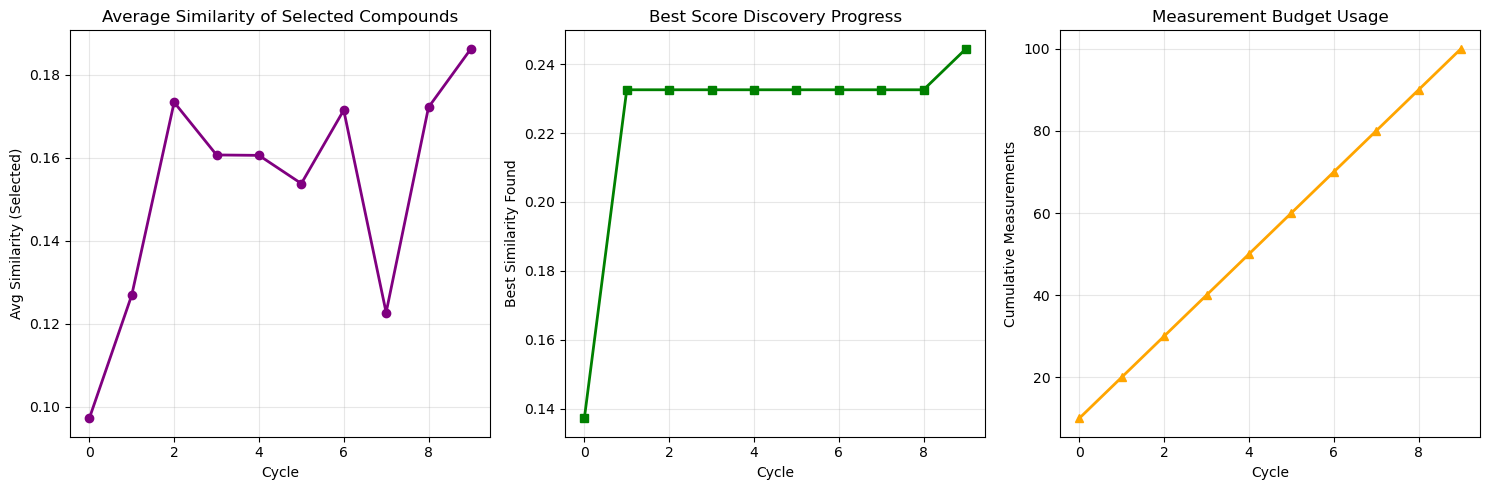


💡 Chemprop Benefits:
  - Works directly with SMILES (no featurizer needed)
  - Learns from molecular graph structure
  - Customizable architecture (depth, hidden dims, dropout)
  - Good for small-to-medium datasets


In [2]:

# Load dataset (1K compounds, ID + SMILES only)
compounds = pl.read_csv('../data/ampc_1k_no_scores.csv')
print(f"Loaded {len(compounds)} compounds for custom learner experiment")

# Create oracle for similarity-based screening
oracle = SimilarityOracle(
    reference_smiles='c1ccc(cc1)C(=O)O',  # Benzoic acid scaffold
    fingerprint_type='morgan',
    metric='tanimoto'
)

print("\n=== Experiment 1: Custom Chemprop Learner ===")
print("Configuring Chemprop MPNN with custom parameters:")
print("  - depth=5 (default=3): More message passing layers")
print("  - message_hidden_dim=500 (default=300): Larger message vectors")
print("  - ffn_num_layers=3 (default=1): Deeper FFN")
print("  - batch_norm=True (default=False): Batch normalization")
print("  - dropout=0.1 (default=0.0): Regularization")

# Create custom Chemprop learner
custom_chemprop = ChempropLearner(
    depth=5,                    # Number of message passing steps
    message_hidden_dim=500,     # Hidden dimension of messages
    ffn_num_layers=3,           # Number of FFN layers
    ffn_hidden_dim=500,         # FFN hidden dimension
    batch_norm=True,            # Enable batch normalization
    dropout=0.1,                # Dropout probability
    max_epochs=30,              # Training epochs
    learning_rate=1e-4,         # Learning rate
    batch_size=32,              # Batch size
    random_state=42             # Reproducibility
)

# Run with custom Chemprop learner
# Note: Chemprop works directly with SMILES (no featurizer needed)
chemprop_results = run_active_learning(
    compound_pool=compounds,           # DataFrame with ID and SMILES
    oracle=oracle,                     # SimilarityOracle
    target_col='similarity',           # Property name
    learner=custom_chemprop,           # Custom Chemprop instance
    # featurizer_type NOT specified - Chemprop uses SMILES directly
    strategy='greedy',                 # Greedy selection
    n_cycles=10,                        # 10 cycles
    batch_fraction=0.01,               # 1% per cycle
    score_direction='higher',           # Higher similarity is better
	output_dir='results/chemprop_greedy/'
)

print(f"\n✓ Custom Chemprop experiment complete!")
print(f"  Compounds measured: {len(chemprop_results['labeled_data'])}")

# Analyze selection quality
measured_df = chemprop_results['labeled_data']
print(f"  Average similarity (selected): {measured_df['similarity'].mean():.3f}")
print(f"  Top similarity found: {measured_df['similarity'].max():.3f}")

# Plot Chemprop performance
chemprop_metrics = pd.DataFrame(chemprop_results['cycle_metrics'])

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(chemprop_metrics['cycle'], chemprop_metrics['avg_score_selected'],
         marker='o', linewidth=2, color='purple')
plt.xlabel('Cycle')
plt.ylabel('Avg Similarity (Selected)')
plt.title('Average Similarity of Selected Compounds')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(chemprop_metrics['cycle'], chemprop_metrics['best_so_far'],
         marker='s', linewidth=2, color='green')
plt.xlabel('Cycle')
plt.ylabel('Best Similarity Found')
plt.title('Best Score Discovery Progress')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(chemprop_metrics['cycle'], chemprop_metrics['cumulative_labeled'],
         marker='^', linewidth=2, color='orange')
plt.xlabel('Cycle')
plt.ylabel('Cumulative Measurements')
plt.title('Measurement Budget Usage')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Chemprop Benefits:")
print("  - Works directly with SMILES (no featurizer needed)")
print("  - Learns from molecular graph structure")
print("  - Customizable architecture (depth, hidden dims, dropout)")
print("  - Good for small-to-medium datasets")

## Section 2: Custom Multi-Stage Cycles

2025-11-21 08:00:30,286 - learnm8.api - INFO - Starting active learning experiment at 2025-11-21 08:00:30.286285
2025-11-21 08:00:30,287 - learnm8.api - INFO - Output directory: results/simple_greedy
2025-11-21 08:00:30,287 - learnm8.api - DEBUG - Normalizing compound_pool input (type: DataFrame)
2025-11-21 08:00:30,288 - learnm8.api - DEBUG - Using provided DataFrame as compound pool
2025-11-21 08:00:30,289 - learnm8.api - DEBUG - Using provided oracle instance: SimilarityOracle
2025-11-21 08:00:30,289 - learnm8.api - DEBUG - Detected run mode (oracle type: SimilarityOracle)
2025-11-21 08:00:30,287 - learnm8.api - INFO - Output directory: results/simple_greedy
2025-11-21 08:00:30,287 - learnm8.api - DEBUG - Normalizing compound_pool input (type: DataFrame)
2025-11-21 08:00:30,288 - learnm8.api - DEBUG - Using provided DataFrame as compound pool
2025-11-21 08:00:30,289 - learnm8.api - DEBUG - Using provided oracle instance: SimilarityOracle
2025-11-21 08:00:30,289 - learnm8.api - DEBUG


=== Experiment 2: Custom Multi-Stage Cycles ===
Demonstrating three approaches to cycle configuration:

1. Simple list: Random → Greedy (exploitation-focused)
2. CycleConfig list: UCB with varying beta (exploration → exploitation)
3. Mixed approach: CycleConfig + simple tuples


Running Strategy 1: Simple List (Random → Greedy)...
  Approach: Pure exploitation after initialization


100%|██████████| 1000/1000 [00:00<00:00, 8557.06it/s]
2025-11-21 08:00:30,418 - learnm8.core.validation - INFO - Validation complete: 1000 valid compounds, 0 invalid compounds (100.0% success rate)
2025-11-21 08:00:30,419 - learnm8.api - INFO - ═══════════════════════════════════════════════════════════════
2025-11-21 08:00:30,419 - learnm8.api - INFO - Phase 2: Initializing master DataFrame (all compounds unlabeled)
2025-11-21 08:00:30,420 - learnm8.api - INFO - ═══════════════════════════════════════════════════════════════
2025-11-21 08:00:30,423 - learnm8.core.initialization - INFO - Initialized master DataFrame: 1000 compounds (all unlabeled)
2025-11-21 08:00:30,424 - learnm8.api - INFO - ═══════════════════════════════════════════════════════════════
2025-11-21 08:00:30,424 - learnm8.api - INFO - Phase 2b: Initialization (Cycle 0) - selecting and measuring initial batch
2025-11-21 08:00:30,425 - learnm8.api - INFO - ═══════════════════════════════════════════════════════════════



Running Strategy 2: CycleConfig List (UCB with Varying Beta)...
  Approach: Start with high exploration (beta=3.0), gradually reduce to exploitation (beta=0.5)


100%|██████████| 1000/1000 [00:00<00:00, 8071.15it/s]
2025-11-21 08:00:33,415 - learnm8.core.validation - INFO - Validation complete: 1000 valid compounds, 0 invalid compounds (100.0% success rate)
2025-11-21 08:00:33,416 - learnm8.api - INFO - ═══════════════════════════════════════════════════════════════
2025-11-21 08:00:33,417 - learnm8.api - INFO - Phase 2: Initializing master DataFrame (all compounds unlabeled)
2025-11-21 08:00:33,418 - learnm8.api - INFO - ═══════════════════════════════════════════════════════════════
2025-11-21 08:00:33,421 - learnm8.core.initialization - INFO - Initialized master DataFrame: 1000 compounds (all unlabeled)
2025-11-21 08:00:33,421 - learnm8.api - INFO - ═══════════════════════════════════════════════════════════════
2025-11-21 08:00:33,422 - learnm8.api - INFO - Phase 2b: Initialization (Cycle 0) - selecting and measuring initial batch
2025-11-21 08:00:33,423 - learnm8.api - INFO - ═══════════════════════════════════════════════════════════════



Running Strategy 3: Mixed Approach (CycleConfig + Tuples)...
  Approach: Initialization → UCB (Exploration) → Greedy (Exploitation)


100%|██████████| 1000/1000 [00:00<00:00, 5822.07it/s]
2025-11-21 08:00:38,960 - learnm8.core.validation - INFO - Validation complete: 1000 valid compounds, 0 invalid compounds (100.0% success rate)
2025-11-21 08:00:38,961 - learnm8.api - INFO - ═══════════════════════════════════════════════════════════════
2025-11-21 08:00:38,962 - learnm8.api - INFO - Phase 2: Initializing master DataFrame (all compounds unlabeled)
2025-11-21 08:00:38,962 - learnm8.api - INFO - ═══════════════════════════════════════════════════════════════
2025-11-21 08:00:38,964 - learnm8.core.initialization - INFO - Initialized master DataFrame: 1000 compounds (all unlabeled)
2025-11-21 08:00:38,965 - learnm8.api - INFO - ═══════════════════════════════════════════════════════════════
2025-11-21 08:00:38,965 - learnm8.api - INFO - Phase 2b: Initialization (Cycle 0) - selecting and measuring initial batch
2025-11-21 08:00:38,966 - learnm8.api - INFO - ═══════════════════════════════════════════════════════════════



✓ All multi-stage strategies complete


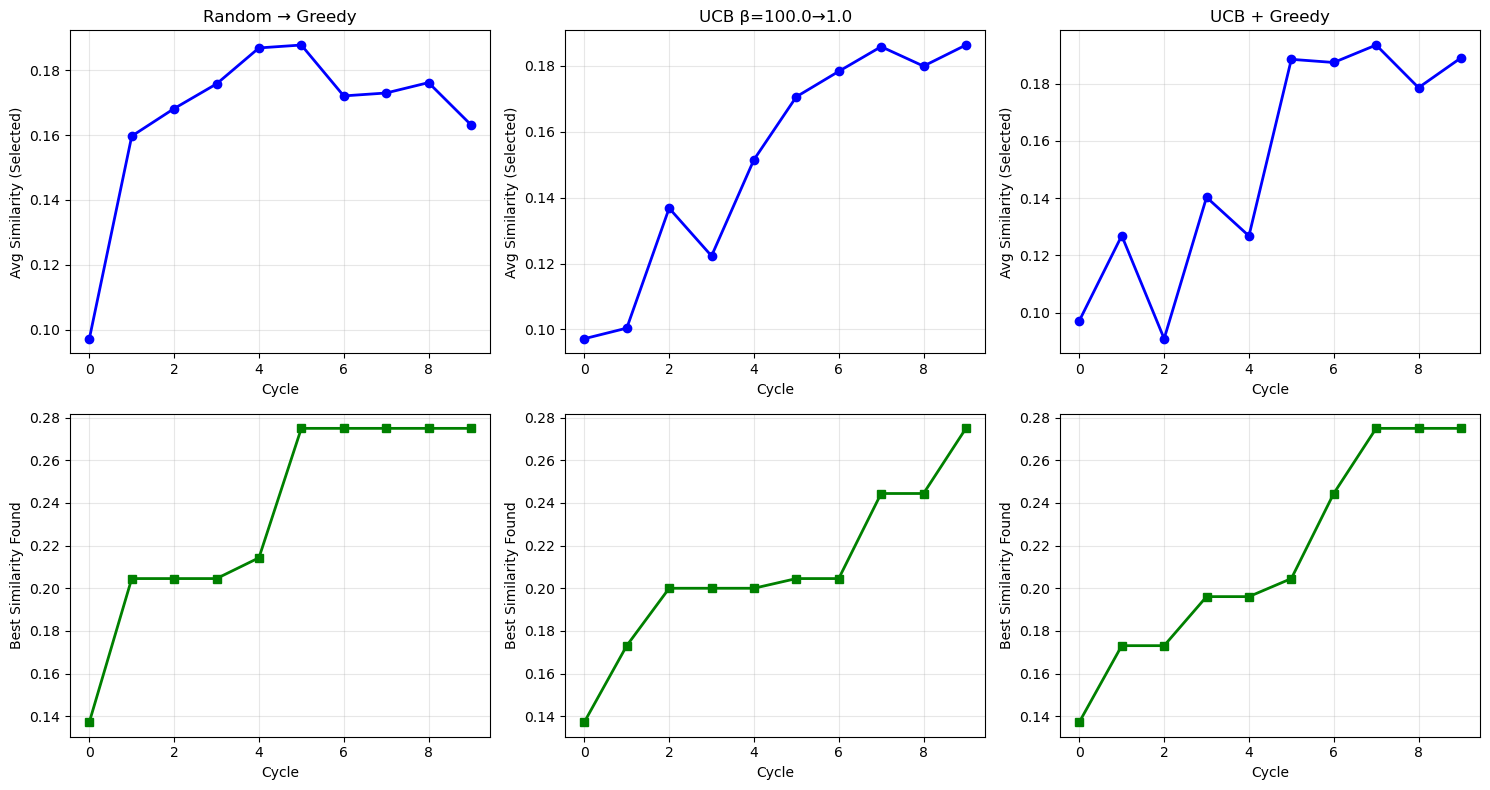


Multi-Stage Strategy Comparison:

Random → Greedy:
  Average similarity (selected): 0.166
  Best similarity found: 0.275
  Total measured: 100

UCB β=100.0→1.0:
  Average similarity (selected): 0.151
  Best similarity found: 0.275
  Total measured: 100

UCB + Greedy:
  Average similarity (selected): 0.152
  Best similarity found: 0.275
  Total measured: 100

💡 Multi-Stage Cycle Configuration Approaches:
  1. Simple List: Easy to use, good for basic workflows (tuples)
  2. CycleConfig List: Full control over acquisition parameters (e.g., beta tuning)
  3. Mixed: Combine simplicity and control where needed

💡 Strategy Insights:
  - Simple List: Pure exploitation maximizes immediate score gains
  - CycleConfig: Gradually reducing beta balances exploration → exploitation
  - Mixed: Flexible approach adapts to workflow requirements


In [ ]:
from learnm8 import CycleConfig

print("\n=== Experiment 2: Custom Multi-Stage Cycles ===")
print("Demonstrating three approaches to cycle configuration using CycleConfig:\n")
print("1. Standard: Random → Greedy (exploitation-focused)")
print("2. Dynamic: UCB with varying beta (exploration → exploitation)")
print("3. Multi-phase: Random → UCB → Greedy\n")

# Strategy 1: Standard definition (random → greedy)
print("\nRunning Strategy 1: Standard (Random → Greedy)...")
print("  Approach: Pure exploitation after initialization")
results_simple = run_active_learning(
	compound_pool=compounds,
	oracle=oracle,
	learner='rf',                      # Random Forest (no uncertainty needed)
	target_col='similarity',
	featurizer_type='morgan',
	cycles=[
		CycleConfig('random', n_cycles=1, batch_fraction=0.01),      # 1% initialization
		CycleConfig('greedy', n_cycles=9, batch_fraction=0.01)       # 1% greedy x4
	],
	score_direction='higher',  # Higher similarity is better
	output_dir='results/simple_greedy/'
)

# Strategy 2: CycleConfig list with custom UCB parameters
print("\nRunning Strategy 2: Dynamic Parameters (UCB with Varying Beta)...")
print("  Approach: Start with high exploration (beta=100.0), gradually reduce to exploitation (beta=1)")
results_config = run_active_learning(
	compound_pool=compounds,
	oracle=oracle,
	learner='rf_ensemble',             # RF Ensemble for UCB uncertainty
	target_col='similarity',
	featurizer_type='morgan',
	cycles=[
		CycleConfig('random', n_cycles=1, batch_fraction=0.01),
		# Smooth descent from beta=100 to beta=1 over 9 cycles (Total 10 cycles)
		CycleConfig('ucb', n_cycles=1, batch_fraction=0.01, acquisition_params={'beta': 100.0}), # Extreme exploration
		CycleConfig('ucb', n_cycles=1, batch_fraction=0.01, acquisition_params={'beta': 50.0}),
		CycleConfig('ucb', n_cycles=1, batch_fraction=0.01, acquisition_params={'beta': 25.0}),
		CycleConfig('ucb', n_cycles=1, batch_fraction=0.01, acquisition_params={'beta': 12.5}),
		CycleConfig('ucb', n_cycles=1, batch_fraction=0.01, acquisition_params={'beta': 6.0}),
		CycleConfig('ucb', n_cycles=1, batch_fraction=0.01, acquisition_params={'beta': 3.0}),
		CycleConfig('ucb', n_cycles=1, batch_fraction=0.01, acquisition_params={'beta': 2.0}),
		CycleConfig('ucb', n_cycles=1, batch_fraction=0.01, acquisition_params={'beta': 1.5}),
		CycleConfig('ucb', n_cycles=1, batch_fraction=0.01, acquisition_params={'beta': 1.0})   # Strong exploitation
	],
	score_direction='higher',
	output_dir='results/cycleconfig_ucb/'
)

# Strategy 3: Multi-phase approach
print("\nRunning Strategy 3: Multi-phase Approach (Random → UCB → Greedy)...")
print("  Approach: Initialization → UCB (Exploration) → Greedy (Exploitation)")
results_mixed = run_active_learning(
	compound_pool=compounds,
	oracle=oracle,
	learner='rf_ensemble',             # RF Ensemble for UCB
	target_col='similarity',
	featurizer_type='morgan',
	cycles=[
		CycleConfig('random', n_cycles=1, batch_fraction=0.01),              # Initialization
		CycleConfig('ucb', n_cycles=4, batch_fraction=0.01,
					acquisition_params={'beta': 10.0}),  # Exploration phase (approx half of remaining)
		CycleConfig('greedy', n_cycles=5, batch_fraction=0.01)               # Exploitation phase (approx half of remaining)
	],
	score_direction='higher',
	output_dir='results/mixed_approach/'
)

print("\n✓ All multi-stage strategies complete")

# Plot comparison (RUN MODE: avg score selected and best score found)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

strategies = [
	(results_simple, 'Random → Greedy'),
	(results_config, 'UCB β=100.0→1.0'),
	(results_mixed, 'UCB + Greedy')
]

for idx, (result, name) in enumerate(strategies):
	metrics = pd.DataFrame(result['cycle_metrics'])
	
	# Top row: Average score selected
	axes[0, idx].plot(metrics['cycle'], metrics['avg_score_selected'],
					  marker='o', linewidth=2, color='blue')
	axes[0, idx].set_title(name)
	axes[0, idx].set_xlabel('Cycle')
	axes[0, idx].set_ylabel('Avg Similarity (Selected)')
	axes[0, idx].grid(True, alpha=0.3)

	# Bottom row: Best score discovered (using pre-calculated metric)
	axes[1, idx].plot(metrics['cycle'], metrics['best_so_far'],
					  marker='s', linewidth=2, color='green')
	axes[1, idx].set_xlabel('Cycle')
	axes[1, idx].set_ylabel('Best Similarity Found')
	axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics (RUN MODE: selection metrics only, not enrichment)
print("\nMulti-Stage Strategy Comparison:")
for result, name in strategies:
	# Get labeled compounds from master DataFrame (polars)
	labeled_df = result['compounds_df'].filter(pl.col('selected_cycle').is_not_null())
	
	avg_score = labeled_df['similarity'].mean()
	top_score = labeled_df['similarity'].max()
	total_measured = len(labeled_df)
	
	print(f"\n{name.replace(chr(10), ' ')}:")  # Remove newlines for print
	print(f"  Average similarity (selected): {avg_score:.3f}")
	print(f"  Best similarity found: {top_score:.3f}")
	print(f"  Total measured: {total_measured}")

print("\n💡 Multi-Stage Cycle Configuration Approaches:")
print("  1. Standard: Good for basic workflows (Random initialization -> Greedy)")
print("  2. Dynamic: Full control over acquisition parameters (e.g., beta tuning)")
print("  3. Multi-phase: Combine different strategies for complex workflows")
print("\n💡 Strategy Insights:")
print("  - Standard: Pure exploitation maximizes immediate score gains")
print("  - Dynamic: Gradually reducing beta balances exploration → exploitation")
print("  - Multi-phase: Flexible approach adapts to workflow requirements")


## Key Insights

**Advanced Configuration Topics:**
1. **Custom Learners**: Chemprop MPNN with custom depth, message passing, FFN layers
2. **Cycle Configuration**: Three approaches (simple lists, CycleConfig with custom params, mixed)
3. **Multi-Stage Workflows**: Design exploration → exploitation transitions
4. **Strategy Comparison**: Evaluate greedy, UCB, EI, Thompson acquisition functions

**Run Mode Metrics:**
- ✅ Average score of selected compounds per cycle
- ✅ Top score found overall
- ✅ Cumulative measurements
- ✅ Selection quality trends
- ❌ Enrichment factor (requires ground truth)
- ❌ Top-K discovery (requires ground truth)

**Custom Learner Configuration:**
- **Chemprop**: Works directly with SMILES (no featurizer)
- Customizable: depth, message_hidden_dim, ffn_num_layers, dropout, batch_norm
- Good for: Small-to-medium datasets, learning from graph structure
- Pass custom learner instance to `run_active_learning(learner=custom_learner)`

**Cycle Configuration Methods:**
1. **Simple Lists:** Use tuples `[('random', 0.02), ('greedy', 0.01), ...]` for straightforward workflows
2. **CycleConfig Objects:** Use `CycleConfig('ucb', n_cycles=1, acquisition_params={'beta': 2.0})` for fine-grained control
3. **Mixed Approach:** Combine both for flexibility (tuples where simple, CycleConfig where custom params needed)

**Multi-Stage Workflow Design:**
1. **Initialization:** Random sampling establishes baseline (1-2%)
2. **Exploration → Exploitation:** Use CycleConfig to gradually adjust parameters (e.g., UCB beta=10.0 → 1.0)
3. **Refinement:** Final greedy cycles to maximize top candidates

**Strategy Selection:**
- **Pure Exploitation:** Simple list with random → greedy (maximizes immediate gains)
- **Adaptive Exploration:** CycleConfig with varying beta (balances exploration → exploitation)
- **Flexible:** Mixed approach adapts to specific workflow needs

**Learner Selection:**
- Use `rf_ensemble` for uncertainty-based strategies (UCB, EI, Thompson)
- Use `rf` for greedy or diversity-based strategies
- Use custom learner instances for specialized architectures (Chemprop, etc.)

**Next:** [04_production_screening.ipynb](04_production_screening.ipynb) for real-world deployment